# Multi-Step Agent: Content Creator

## Overview

This notebook demonstrates a multi-step agent that creates content through a structured workflow:

**Research → Outline → Draft → Review → Publish**

Each step uses different tools and approaches to transform the content progressively.

In [ ]:
# Install required packages
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph langgraph-prebuilt langchain_community tavily-python

In [2]:
# Load environment variables
from pathlib import Path
from dotenv import load_dotenv
import os

# Try multiple possible locations for .env file
possible_paths = [
    Path.cwd().parent / '.env',  # Parent directory
    Path.cwd() / '.env',         # Current directory
    Path('.env')                 # Relative path
]

for path in possible_paths:
    if path.exists():
        load_dotenv(dotenv_path=path)
        print(f"Loaded .env from: {path}")
        break
else:
    print("No .env file found in expected locations")

print("Environment variables loaded:")
print("OPENAI_API_KEY:", "[LOADED]" if os.getenv("OPENAI_API_KEY") else "Not found")
print("TAVILY_API_KEY:", "[LOADED]" if os.getenv("TAVILY_API_KEY") else "Not found")

Loaded .env from: /Users/kazhian/Dev/agentic_ai/.env
Environment variables loaded:
OPENAI_API_KEY: [LOADED]
TAVILY_API_KEY: [LOADED]


In [ ]:
# LangSmith setup for tracing
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "content-creator-agent"

## State Definition

We'll define a custom state that tracks the content through each stage of creation.

In [3]:
from typing_extensions import TypedDict
from typing import List, Optional
from langchain_core.messages import HumanMessage, AIMessage

class ContentState(TypedDict):
    """State for content creation workflow"""
    messages: List[HumanMessage | AIMessage]  # Conversation history
    topic: str                              # Content topic
    research_data: Optional[str]            # Research findings
    outline: Optional[str]                   # Content outline
    draft: Optional[str]                     # Content draft
    review_feedback: Optional[str]          # Review feedback
    final_content: Optional[str]             # Final published content
    current_stage: str                      # Current workflow stage

## Tools Definition

Each stage of the workflow requires specific tools:

In [4]:
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

# Initialize models and search
llm = ChatOpenAI(model="gpt-4o", temperature=0.7)
tavily_search = TavilySearchResults(max_results=5)

@tool
def research_topic(topic: str) -> str:
    """Research a given topic using web search."""
    search_query = f"research information about {topic} key facts statistics trends"
    search_results = tavily_search.invoke(search_query)
    
    # Combine search results into research summary
    research_summary = f"Research on {topic}:\n\n"
    for i, result in enumerate(search_results, 1):
        research_summary += f"Source {i}: {result.get('title', 'No title')}\n"
        research_summary += f"Content: {result.get('content', 'No content')[:500]}...\n\n"
    
    return research_summary

@tool
def create_outline(topic: str, research_data: str) -> str:
    """Create a structured outline based on research."""
    outline_prompt = f"""
    Based on the following research about {topic}, create a comprehensive outline for a blog post or article.
    
    Research Data:
    {research_data}
    
    Create a structured outline with:
    1. Catchy title
    2. Introduction (hook + thesis)
    3. Main sections (3-5 key points)
    4. Conclusion (summary + call to action)
    
    Format as a clear hierarchical outline.
    """
    
    response = llm.invoke([HumanMessage(content=outline_prompt)])
    return response.content

@tool
def write_draft(topic: str, outline: str) -> str:
    """Write a full draft based on the outline."""
    draft_prompt = f"""
    Write a comprehensive blog post about {topic} based on the following outline.
    
    Outline:
    {outline}
    
    Guidelines:
    - Write in an engaging, informative style
    - Include all sections from the outline
    - Aim for 800-1200 words
    - Use clear headings and transitions
    - Include practical examples where appropriate
    
    Write the complete article:
    """
    
    response = llm.invoke([HumanMessage(content=draft_prompt)])
    return response.content

@tool
def review_content(draft: str) -> str:
    """Review and provide feedback on the draft."""
    review_prompt = f"""
    Review the following article draft and provide constructive feedback.
    
    Draft:
    {draft}
    
    Evaluate on:
    1. Clarity and readability
    2. Structure and flow
    3. Content accuracy and completeness
    4. Engagement and style
    5. Grammar and mechanics
    
    Provide specific feedback and suggestions for improvement.
    If the draft needs major revisions, say "NEEDS_REVISION".
    If the draft is good to publish, say "READY_TO_PUBLISH".
    """
    
    response = llm.invoke([HumanMessage(content=review_prompt)])
    return response.content

@tool
def format_for_publishing(draft: str, review_feedback: str) -> str:
    """Format the content for final publication."""
    format_prompt = f"""
    Format the following article for final publication based on the review feedback.
    
    Draft:
    {draft}
    
    Review Feedback:
    {review_feedback}
    
    Apply the feedback and format the final article with:
    - Clear, compelling title
    - Proper heading structure (H1, H2, H3)
    - Short paragraphs for readability
    - Bullet points where appropriate
    - Strong conclusion and call to action
    - Word count target: 600-1000 words
    
    Return the final publish-ready article.
    """
    
    response = llm.invoke([HumanMessage(content=format_prompt)])
    return response.content

/var/folders/72/w673qd2n1h70zv_y14phwxph0000gp/T/ipykernel_21059/1187331568.py:7: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=5)


## Workflow Nodes

Each stage of the content creation process is a separate node in our graph.

In [5]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

def research_node(state: ContentState) -> ContentState:
    """Research stage: Gather information about the topic."""
    print("🔍 Starting Research Stage...")
    
    # Use the research tool
    research_result = research_topic.invoke({"topic": state["topic"]})
    
    # Update state
    state["research_data"] = research_result
    state["current_stage"] = "research_complete"
    
    print(f"✅ Research completed for topic: {state['topic']}")
    return state

def outline_node(state: ContentState) -> ContentState:
    """Outline stage: Create content structure."""
    print("📝 Starting Outline Stage...")
    
    # Use the outline tool
    outline_result = create_outline.invoke({
        "topic": state["topic"], 
        "research_data": state["research_data"]
    })
    
    # Update state
    state["outline"] = outline_result
    state["current_stage"] = "outline_complete"
    
    print("✅ Outline created successfully")
    return state

def draft_node(state: ContentState) -> ContentState:
    """Draft stage: Write the full content."""
    print("✍️ Starting Draft Stage...")
    
    # Use the draft tool
    draft_result = write_draft.invoke({
        "topic": state["topic"], 
        "outline": state["outline"]
    })
    
    # Update state
    state["draft"] = draft_result
    state["current_stage"] = "draft_complete"
    
    print("✅ Draft completed")
    return state

def review_node(state: ContentState) -> ContentState:
    """Review stage: Evaluate and provide feedback."""
    print("🔍 Starting Review Stage...")
    
    # Use the review tool
    review_result = review_content.invoke({"draft": state["draft"]})
    
    # Update state
    state["review_feedback"] = review_result
    state["current_stage"] = "review_complete"
    
    print("✅ Review completed")
    return state

def publish_node(state: ContentState) -> ContentState:
    """Publish stage: Format and prepare final content."""
    print("🚀 Starting Publish Stage...")
    
    # Use the format tool
    final_result = format_for_publishing.invoke({
        "draft": state["draft"], 
        "review_feedback": state["review_feedback"]
    })
    
    # Update state
    state["final_content"] = final_result
    state["current_stage"] = "published"
    
    print("✅ Content published successfully!")
    return state

def should_revise(state: ContentState) -> str:
    """Determine if content needs revision based on review."""
    feedback = state.get("review_feedback", "").lower()
    
    if "needs_revision" in feedback:
        print("🔄 Content needs revision - returning to draft stage")
        return "revise"
    else:
        print("✅ Content approved - proceeding to publish")
        return "publish"

## Graph Construction

Build the workflow graph with all stages and conditional routing.

In [9]:
# Build the workflow graph
builder = StateGraph(ContentState)

# Add nodes
builder.add_node("research", research_node)
builder.add_node("outline", outline_node)
builder.add_node("draft", draft_node)
builder.add_node("review", review_node)
builder.add_node("publish", publish_node)

# Define the workflow flow
builder.add_edge(START, "research")
builder.add_edge("research", "outline")
builder.add_edge("outline", "draft")
builder.add_edge("draft", "review")

# Conditional edge: either revise (back to draft) or publish
builder.add_conditional_edges(
    "review",
    should_revise,
    {
        "revise": "draft",  # Go back to draft for revision
        "publish": "publish"  # Proceed to publish
    }
)

builder.add_edge("publish", END)

# Compile with memory for persistence
memory = MemorySaver()
content_creator_graph = builder.compile(checkpointer=memory)

print("🎯 Content Creator Graph built successfully!")

🎯 Content Creator Graph built successfully!


## Graph Visualization

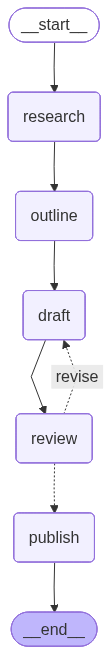

In [10]:
# Display the graph structure
try:
    from IPython.display import Image, display
    display(Image(content_creator_graph.get_graph(xray=True).draw_mermaid_png()))
except:
    print("Graph visualization not available in this environment")
    print("Graph structure:")
    print("START → research → outline → draft → review → [revise → draft] OR publish → END")

## Demo Execution

Let's test our content creator agent with a sample topic.

In [11]:
# Initialize the workflow
initial_state = {
    "messages": [],
    "topic": "The Future of Artificial Intelligence in Healthcare",
    "research_data": None,
    "outline": None,
    "draft": None,
    "review_feedback": None,
    "final_content": None,
    "current_stage": "starting"
}

# Configure thread ID for persistence
config = {"configurable": {"thread_id": "content_creator_demo"}}

print("🎬 Starting Content Creation Workflow...")
print(f"📋 Topic: {initial_state['topic']}")
print("=" * 50)

# Run the workflow
result = content_creator_graph.invoke(initial_state, config)

print("=" * 50)
print("🎉 Workflow Complete!")
print(f"📊 Final Stage: {result['current_stage']}")
print(f"📄 Content Length: {len(result.get('final_content', ''))} characters")

🎬 Starting Content Creation Workflow...
📋 Topic: The Future of Artificial Intelligence in Healthcare
🔍 Starting Research Stage...
✅ Research completed for topic: The Future of Artificial Intelligence in Healthcare
📝 Starting Outline Stage...
✅ Outline created successfully
✍️ Starting Draft Stage...
✅ Draft completed
🔍 Starting Review Stage...
✅ Review completed
🔄 Content needs revision - returning to draft stage
✍️ Starting Draft Stage...
✅ Draft completed
🔍 Starting Review Stage...
✅ Review completed
🔄 Content needs revision - returning to draft stage
✍️ Starting Draft Stage...
✅ Draft completed
🔍 Starting Review Stage...
✅ Review completed
🔄 Content needs revision - returning to draft stage
✍️ Starting Draft Stage...
✅ Draft completed
🔍 Starting Review Stage...
✅ Review completed
✅ Content approved - proceeding to publish
🚀 Starting Publish Stage...
✅ Content published successfully!
🎉 Workflow Complete!
📊 Final Stage: published
📄 Content Length: 4326 characters


## Results Display

In [13]:
# Display the final content
final_content = result.get('final_content', 'No final content available')

if final_content:
    print("📖 FINAL PUBLISHED CONTENT:")
    print("=" * 80)
    print(final_content)
    print("=" * 80)
else:
    print("❌ No final content generated")

# Show workflow progression
print("\n🔄 WORKFLOW PROGRESSION:")
print(f"✅ Research: {'✓' if result.get('research_data') else '✗'}")
print(f"✅ Outline: {'✓' if result.get('outline') else '✗'}")
print(f"✅ Draft: {'✓' if result.get('draft') else '✗'}")
print(f"✅ Review: {'✓' if result.get('review_feedback') else '✗'}")
print(f"✅ Final: {'✓' if result.get('final_content') else '✗'}")

📖 FINAL PUBLISHED CONTENT:
# Revolutionizing Healthcare: The Future of AI in Medicine

## Introduction

Imagine a world where your healthcare provider can diagnose illnesses faster and more accurately, where administrative burdens are minimized, and patient care is more personalized and efficient than ever before. This vision is rapidly becoming reality with the integration of artificial intelligence (AI) into healthcare. AI is transforming patient care, operational efficiency, and clinical outcomes, heralding a new era of healthcare innovation and excellence.

## The Current Impact of AI in Healthcare

AI's influence in healthcare is already significant, particularly in patient safety and operational efficiency:

- **Patient Safety**: AI technologies have reduced door-to-provider times by 37% and decreased triage decision errors by 52%, enhancing overall patient safety and care quality in emergency situations.
- **Operational Efficiency**: AI-driven documentation platforms have cut do

## Interactive Demo

Try the content creator with your own topic!

In [ ]:
# Interactive content creation
user_topic = input("Enter a topic for content creation: ") or "Sustainable Technology Trends"

# Initialize new workflow
user_state = {
    "messages": [],
    "topic": user_topic,
    "research_data": None,
    "outline": None,
    "draft": None,
    "review_feedback": None,
    "final_content": None,
    "current_stage": "starting"
}

# Configure new thread
user_config = {"configurable": {"thread_id": f"content_creator_{hash(user_topic) % 10000}"}}

print(f"🎬 Creating content about: {user_topic}")
print("=" * 50)

# Run the workflow
user_result = content_creator_graph.invoke(user_state, user_config)

print("=" * 50)
print("🎉 Your content is ready!")
print("\n📖 FINAL CONTENT:")
print("-" * 50)
print(user_result.get('final_content', 'Content generation failed'))
print("-" * 50)

## Summary

This multi-step agent demonstrates:

### ✅ **Key Features**
1. **Structured Workflow**: Clear Research → Outline → Draft → Review → Publish pipeline
2. **Tool Integration**: Each stage uses specialized tools for specific tasks
3. **Conditional Logic**: Revision loop based on review feedback
4. **State Management**: Tracks progress through each stage
5. **Memory Persistence**: Maintains conversation context

### 🔧 **Technical Components**
- **LangGraph**: Workflow orchestration and state management
- **LangChain Tools**: Specialized functions for each stage
- **MemorySaver**: Persistent state across executions
- **Conditional Edges**: Dynamic routing based on review outcomes

### 🚀 **Use Cases**
- **Content Marketing**: Automated blog post creation
- **Documentation**: Technical writing and guides
- **Social Media**: Multi-platform content adaptation
- **Academic Writing**: Research papers and articles

### 🎯 **Benefits**
- **Consistency**: Standardized content creation process
- **Quality Control**: Built-in review and revision loop
- **Scalability**: Can handle multiple content requests
- **Flexibility**: Easy to modify stages and tools

This approach combines the reliability of structured chains with the intelligence of agents, creating a robust content creation system.